In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import plotly.express as px


In [4]:
df=pd.read_csv("startup_failures.csv")
df.head()

,Startup,Description,Founders,Country,Industry,Started in,Closed in,Employees,Funding Amount,Failure Cause
0,Auctionata,Auctionata was an online auction platform for ...,"Alexander Gilkes, Alexander Zacke, Georg Unter...",Germany,e-Commerce,2012,2017,250-500,> $50M,Legal Challenges
1,Moped,Moped was a free social app. It had not enough...,Schuyler Deerman,Germany,Social Media,1998,2014,10-50,$1M-$10M,No Market Need
2,ABBY,ABBY was a documentation service for A/B tests...,Andy Goldschmidt,Germany,Analytics,2015,2016,NaN,$0,No Market Need
3,Flux,Flux was a modular multi messaging client. The...,Jan Johannes,Germany,Software & Hardware,2011,2016,NaN,< $100K,Bad Management
4,Gameslog,Gameslog was a gaming site monetized with affi...,Michael Hebenstreit,Germany,Entertainment,2013,2014,NaN,$0,Competition


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Startup         186 non-null    object
 1   Description     186 non-null    object
 2   Founders        186 non-null    object
 3   Country         186 non-null    object
 4   Industry        186 non-null    object
 5   Started in      186 non-null    int64 
 6   Closed in       186 non-null    object
 7   Employees       91 non-null     object
 8   Funding Amount  186 non-null    object
 9   Failure Cause   186 non-null    object
dtypes: int64(1), object(9)
memory usage: 14.7+ KB


In [6]:
df.isnull().sum()

Startup            0
Description        0
Founders           0
Country            0
Industry           0
Started in         0
Closed in          0
Employees         95
Funding Amount     0
Failure Cause      0
dtype: int64

there are many nan values in Employees column ,i am not dropping it and just keeping it a zero .

In [7]:
df['Closed in'] = df['Closed in'].replace('Active', 2026)
df['Closed in'] = pd.to_numeric(df['Closed in'], errors='coerce')

df["Lifetime"]=df["Closed in"]-df["Started in"]

In [8]:
def clean_funding(x):
    if pd.isna(x):
        return None
    
    x = str(x).lower().strip()

    if x in ['no data', 'unknown', 'n/a', '-', '']:
        return None

    x = x.replace(',', '')

    if x == '$0':
        return 0

    if '-' in x:
        low, high = x.split('-')
        return (convert_to_million(low) + convert_to_million(high)) / 2

    if '>' in x:
        return convert_to_million(x.replace('>', '').strip())

    if '<' in x:
        return convert_to_million(x.replace('<', '').strip())

    return convert_to_million(x)


def convert_to_million(val):
    val = val.replace('$', '').strip().lower()

    if val in ['no data', 'unknown', 'n/a', '-', '']:
        return None

    if 'k' in val:
        return float(val.replace('k', '')) / 1000

    elif 'm' in val:
        return float(val.replace('m', ''))

    else:
        try:
            return float(val) / 1_000_000
        except:
            return None  

df['Funding_clean'] = df['Funding Amount'].apply(clean_funding)

In this above cell we are cleaning the funding column and storing it into Funding_clean and if the funding is in some range thenn we are taking it's average.

In [9]:
df['Funding_clean'] = df['Funding_clean'].fillna(df['Funding_clean'].median())

There are 10 nan value in the Funding_clean new column so i am just filling it with the median.

In [10]:
df.describe()

,Started in,Closed in,Lifetime,Funding_clean
count,186.000000,186.000000,186.000000,186.000000
mean,2013.086022,2016.188172,3.102151,9.139247
std,4.036739,3.167755,3.193794,16.543793
min,1994.000000,2002.000000,0.000000,0.000000
25%,2011.000000,2015.000000,1.000000,0.000000
50%,2014.000000,2016.000000,2.000000,0.300000
75%,2015.000000,2018.000000,4.000000,5.500000
max,2020.000000,2026.000000,17.000000,50.000000


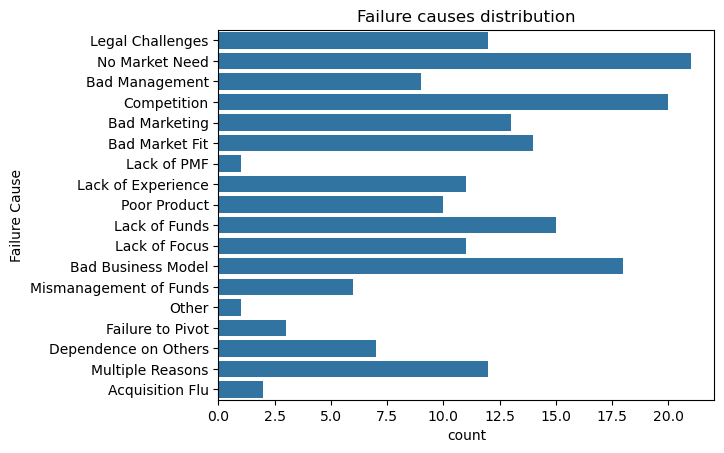

In [11]:
sns.countplot(df["Failure Cause"])
plt.title("Failure causes distribution")
plt.show()

### Market-related and Management-related failures are the most common, together accounting for the majority of startup shutdowns. This aligns with industry research showing that lack of product-market fit and founder/team issues are the leading causes of startup failure.

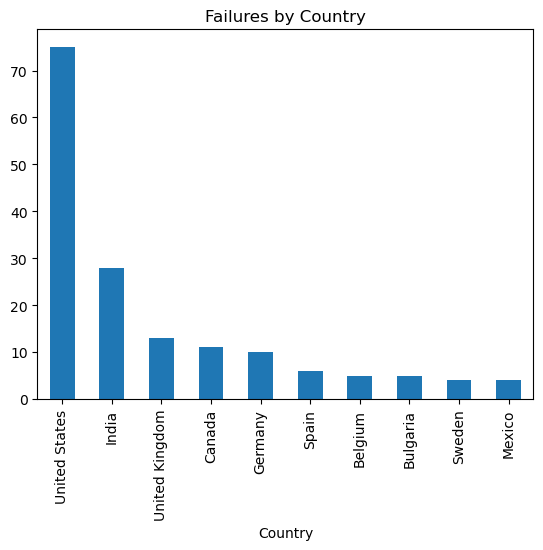

In [12]:
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Failures by Country")
plt.show()

United stated has the highest number of startups failed followed by india.

In [13]:
fig=px.pie(df,names="Industry",title="Industry wise failure percentage")
fig.show()

### E-commerce and tech-adjacent industries dominate simply because they attract the most startup activity. Raw count does not imply those industries have higher failure rates than others.

<Figure size 1200x500 with 0 Axes>

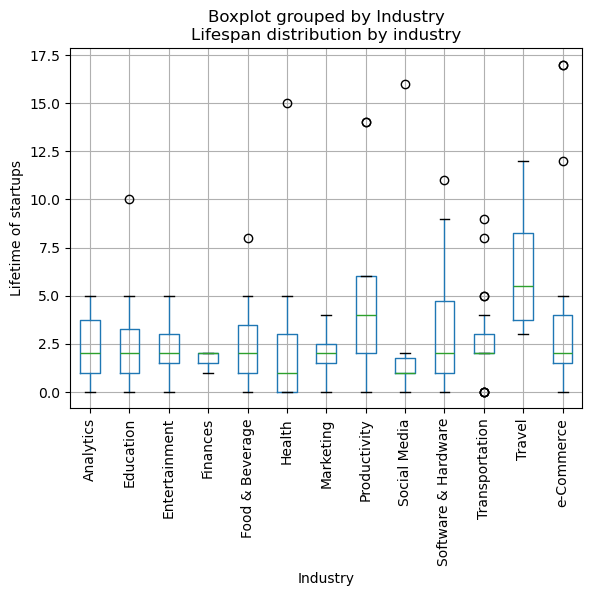

In [38]:
plt.figure(figsize=(12,5))
df.boxplot(column='Lifetime', by='Industry')
plt.title("Lifespan distribution by industry")
plt.ylabel("Lifetime of startups")
plt.xticks(rotation=90)
plt.show()

Startups in industries like Health and Transportation show wider variability in lifespans, while sectors such as Education and Productivity tend to have more consistent, shorter durations. Overall, longevity differs greatly by industry, highlighting how market dynamics shape survival.

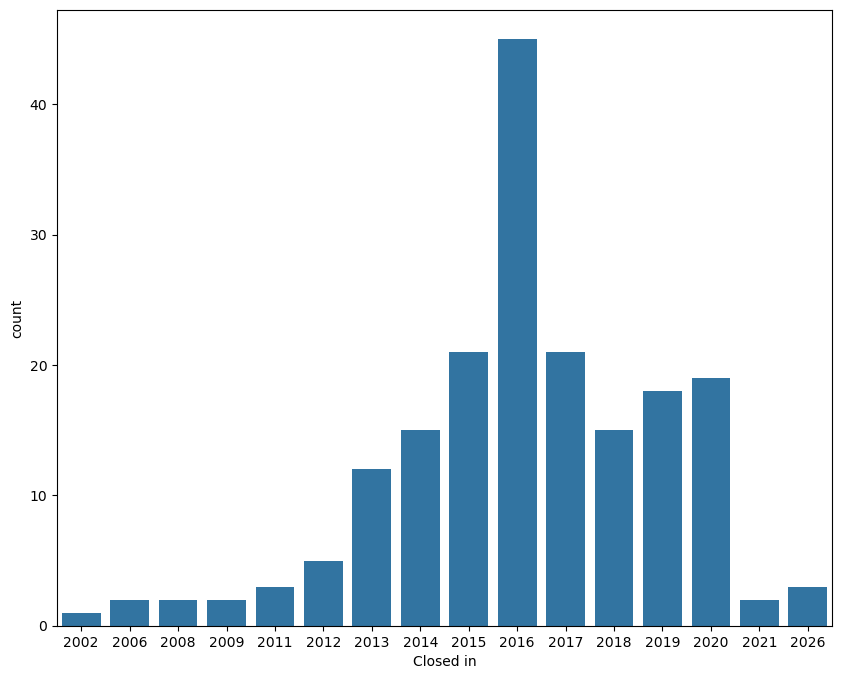

In [15]:
plt.figure(figsize=(10,8))
sns.countplot(x=df["Closed in"])
plt.show()

#### Peaks around 2015–2019 reflect both increased startup activity and the time lag between founding and failure — startups founded in the 2010–2015 wave failing 3–5 years later.
#### Recent years (2022–2024) may be underrepresented because recently failed startups may not yet be fully documented on Failory.
#### Any spike around 2008–2009 or 2020 would suggest economic shocks (financial crisis, COVID-19) accelerating failures.
#### Startup failures are not uniformly distributed over time — they cluster around economic downturns and lag startup boom periods by 2–4 years, reflecting the typical runway before funds run out.

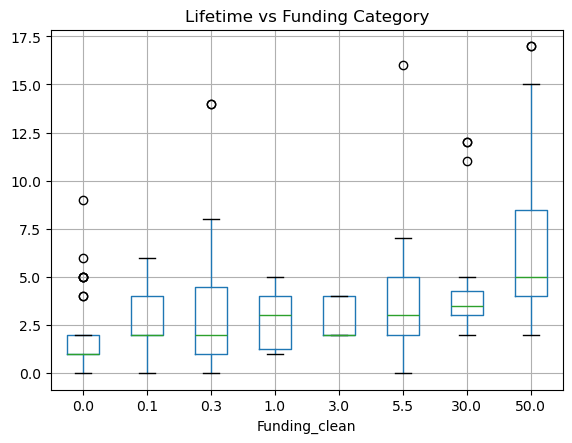

In [16]:
df.boxplot(column='Lifetime', by='Funding_clean')
plt.title("Lifetime vs Funding Category")
plt.suptitle('')
plt.show()

#### Funding level influences the range of possible outcomes more than the expected outcome. A well-funded startup can fail just as fast as an unfunded one if the underlying problem is market or management related.

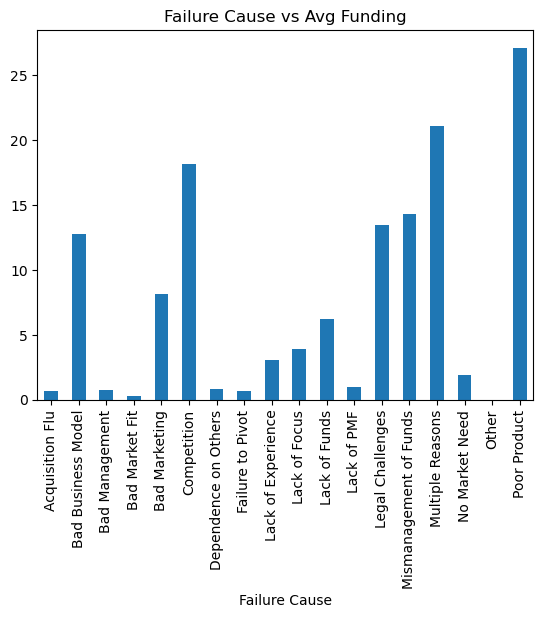

In [17]:
df.groupby('Failure Cause')['Funding_clean'].mean().plot(kind='bar')
plt.title("Failure Cause vs Avg Funding")
plt.show()

#### The relationship between funding and failure cause is not linear. The type of problem, not the amount of money, determines how a startup fails. External and legal issues hit later-stage companies; product and market issues hit earlier-stage ones.

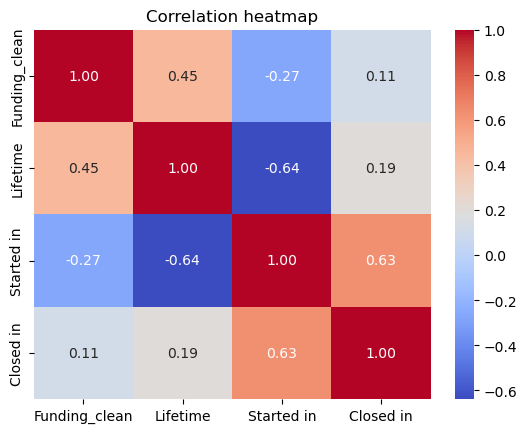

In [39]:
corr = df[['Funding_clean','Lifetime','Started in',"Closed in"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation heatmap")
plt.show()

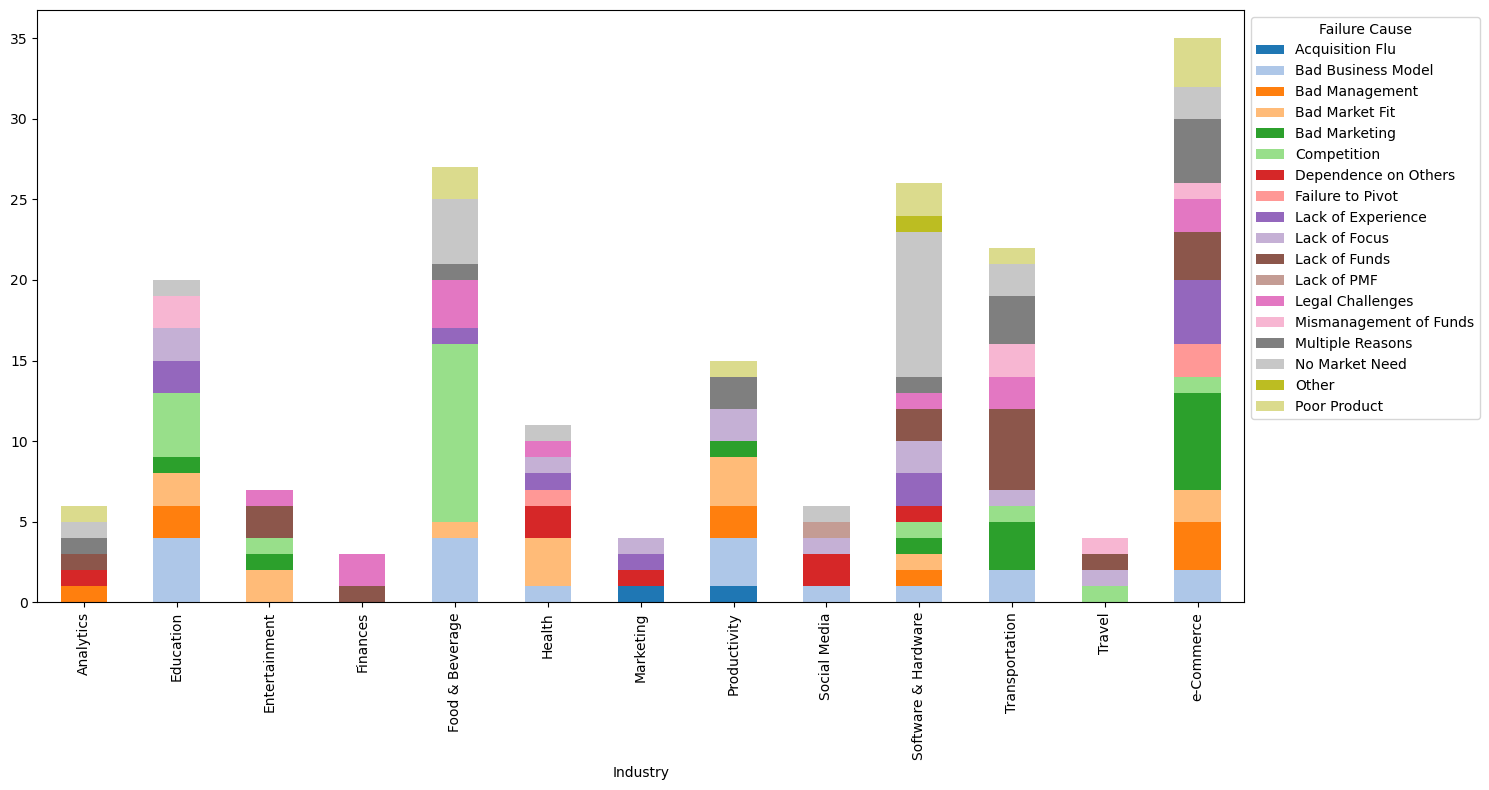

In [50]:
colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
ax = pd.crosstab(df['Industry'], df['Failure Cause']).plot(kind='bar', stacked=True, figsize=(15,8), color=colors[:len(df['Failure Cause'].unique())])
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Failure Cause')
plt.tight_layout()
plt.show()

The chart highlights that Food & Beverage, Education, and Software & Hardware industries face the highest failure counts.
Across sectors, Lack of Funds and Competition emerge as dominant causes, cutting across multiple industries.
Some industries like Health and Transportation show more diverse reasons, indicating complex challenges beyond funding.
Overall, the visualization underscores how startup survival is shaped by both sector‑specific dynamics and universal pitfalls.

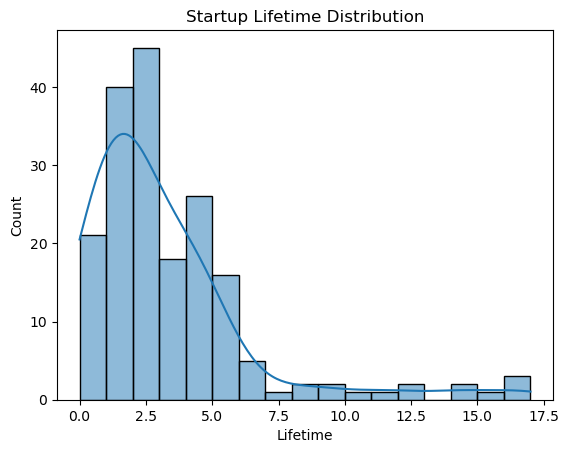

In [20]:
sns.histplot(df["Lifetime"],kde=True)
plt.title("Startup Lifetime Distribution")
plt.show()


Distribution of the lifetime data and it is right skewed

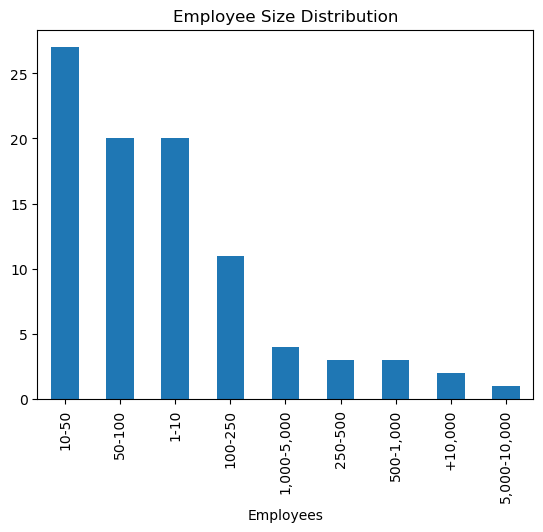

In [21]:
df['Employees'].value_counts().plot(kind='bar')
plt.title("Employee Size Distribution")
plt.show()

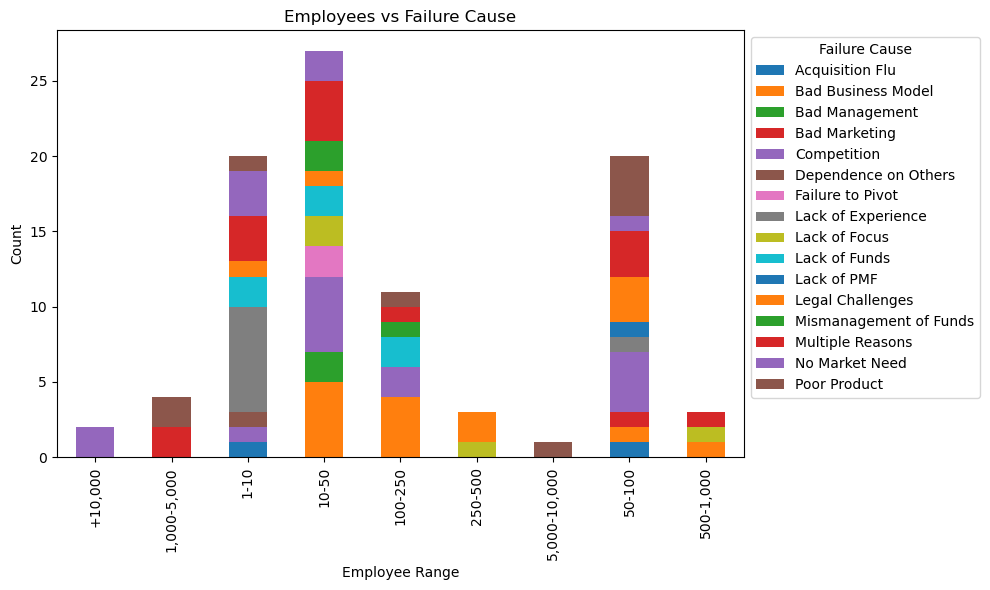

In [22]:
ax = pd.crosstab(df['Employees'], df['Failure Cause']).plot(kind='bar', stacked=True,figsize=(10, 6))
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Failure Cause')
plt.title("Employees vs Failure Cause")
plt.xlabel("Employee Range")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

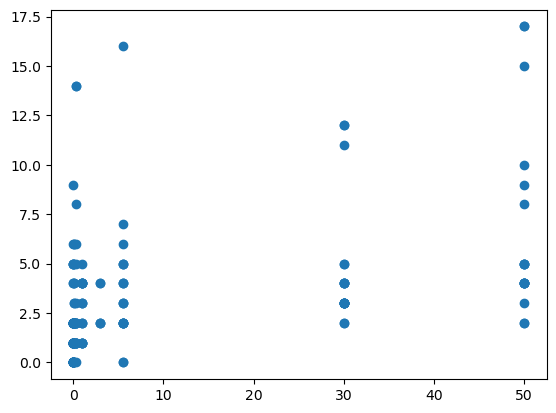

In [23]:
plt.scatter(df["Funding_clean"],df["Lifetime"])
plt.show()

In [24]:
mapping = {
    'Lack of Funds': 'Financial',
    'Mismanagement of Funds': 'Financial',
    'No Market Need': 'Market',
    'Bad Market Fit': 'Market',
    'Competition': 'Market',
    'Bad Marketing': 'Market',
    'Lack of PMF': 'Market',
    'Poor Product': 'Product',
    'Bad Management': 'Management',
    'Lack of Experience': 'Management',
    'Lack of Focus': 'Management',
    'Bad Business Model': 'Management',
    'Failure to Pivot': 'Management',
    'Legal Challenges': 'External',
    'Dependence on Others': 'External',
    'Acquisition Flu': 'External',
    'Multiple Reasons': 'Other',
    'Other': 'Other'
}
y=df["Failure Cause"].map(mapping)

In [25]:
from sklearn.preprocessing import StandardScaler

industry=pd.get_dummies(df["Industry"],drop_first=True)
X = pd.concat([df[['Funding_clean','Lifetime']], industry], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=8,weights='distance')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

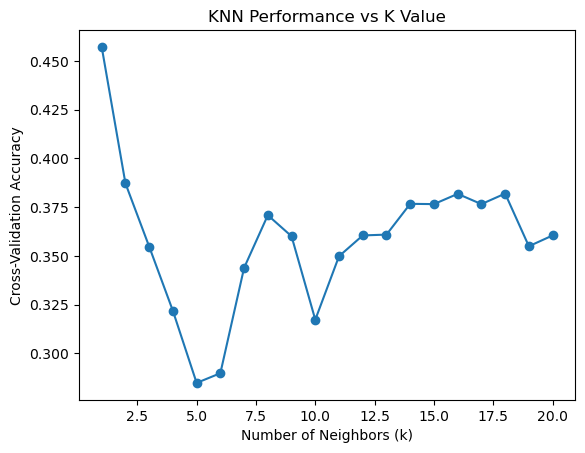

In [28]:
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
          X_scaled, y, cv=5, scoring='accuracy').mean() for k in k_range]
plt.plot(k_range, scores, marker='o')
plt.title("KNN Performance vs K Value")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.show()

In [29]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.42105263157894735
              precision    recall  f1-score   support

    External       0.50      0.50      0.50         4
   Financial       0.29      0.50      0.36         4
  Management       0.50      0.25      0.33        12
      Market       0.50      0.73      0.59        11
       Other       0.00      0.00      0.00         3
     Product       0.33      0.25      0.29         4

    accuracy                           0.42        38
   macro avg       0.35      0.37      0.35        38
weighted avg       0.42      0.42      0.40        38



####  Summary: Model Performance (≈42.1% Accuracy)

- The model achieves **~42.1% accuracy** due to **limited and imbalanced data**.  
- Many classes have **very few samples**, making it hard for the model to learn patterns.  
- Features like **funding, industry, and lifetime** are **not strong indicators** of failure reasons.  
- Several failure categories are **overlapping and not clearly separable**.  
- The **KNN algorithm**, being distance-based, struggles when similar data points have different outcomes.  

####  Conclusion  
The low accuracy is mainly due to **data limitations and problem complexity**, not implementation errors. Grouping categories improved performance, but further improvement requires better data and features.

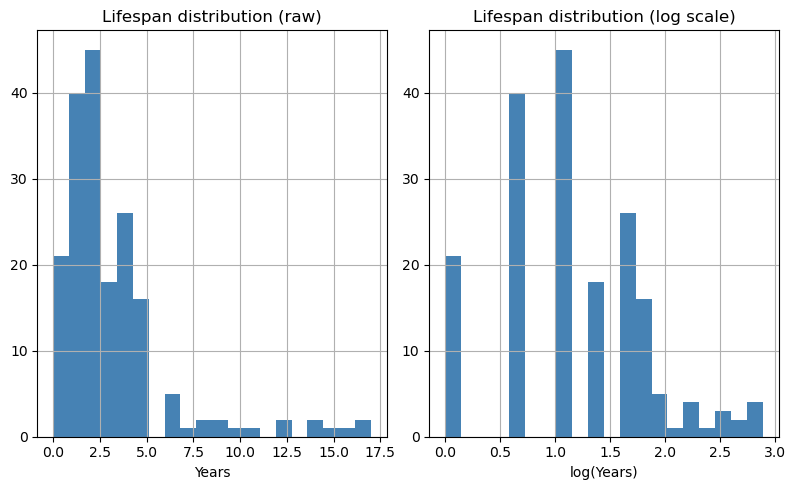

In [30]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
df['Lifetime'].hist(bins=20,color='steelblue')
plt.title('Lifespan distribution (raw)')
plt.xlabel('Years')

plt.subplot(1,2,2)
np.log1p(df['Lifetime']).hist(bins=20,color='steelblue')
plt.title('Lifespan distribution (log scale)')
plt.xlabel('log(Years)')

plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import LinearRegression


X = df[['Funding_clean']]
X = pd.concat([X, pd.get_dummies(df['Industry'])], axis=1)

y = np.log1p(df['Lifetime'])


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 0.3863155763963555
RMSE: 0.5403802932813832
R2 Score: 0.3960943918008286


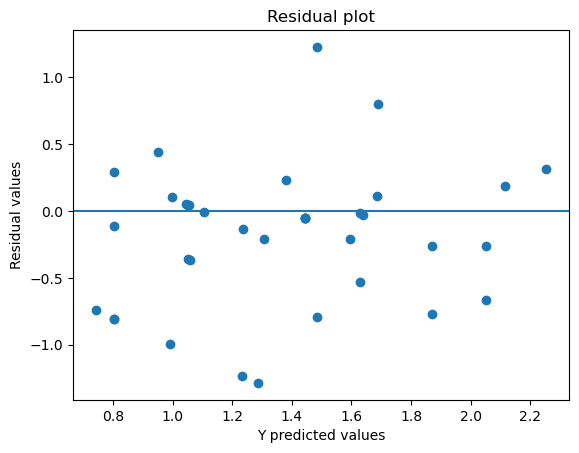

In [35]:
residual=y_test-y_pred

plt.scatter(y_pred,residual)
plt.axhline(y=0)
plt.xlabel("Y predicted values")
plt.ylabel("Residual values")
plt.title("Residual plot")
plt.show()

####    The residual plot after log transformation shows a more random distribution around zero, indicating improved linearity and reduced heteroscedasticity. However, some spread still exists, suggesting that the model does not fully capture all underlying factors affecting the target variable.

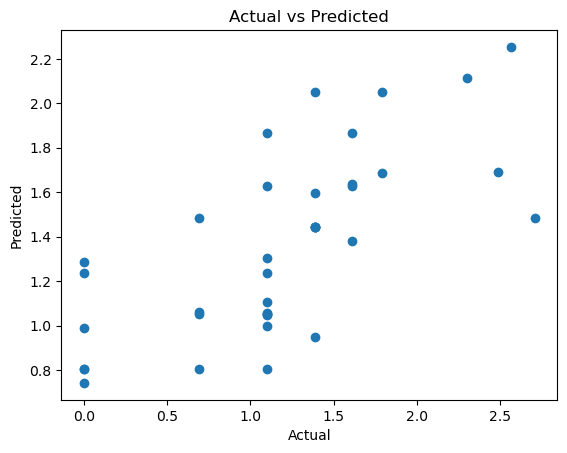

In [36]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()